## Homework Session 6 - 2.5D DC Resistivity Inversion

The objective of this homework is to perform a 2.5D inversion of DC resistivity data from simulated data from a simple 2D model. The task consists of inverting using the following regularization methods:
- Weigthed Least Squares $\rightarrow$ smooth model
- Iteratively Reweighted Least Squares $\rightarrow$ blocky model

In [2]:
# SimPEG functionality
from simpeg.electromagnetics.static import resistivity as dc
from simpeg.electromagnetics.static.utils.static_utils import (
    plot_pseudosection,
    generate_survey_from_abmn_locations,
    apparent_resistivity_from_voltage,
)
from simpeg.utils.io_utils.io_utils_electromagnetics import read_dcip2d_ubc
from simpeg.utils import download, model_builder
from simpeg import (
    maps,
    data,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
)

# discretize functionality
from discretize import TreeMesh
from discretize.utils import active_from_xyz

# Basic Python functionality
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import tarfile

mpl.rcParams.update({"font.size": 14})  # default font size
cmap = mpl.cm.RdYlBu_r  # default colormap

In [6]:
# path to the directory containing our data
dir_path = ".\data"

# files to work with
topo_filename = os.path.join(dir_path, "topo_2d.txt")
data_filename = os.path.join(dir_path, "dc_data.obs")

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\u_ber\AppData\Local\Temp\ipykernel_20468\3345435680.py:2: SyntaxWarning: invalid escape sequence '\d'
  dir_path = ".\data"


The format for this DC resistivity data is as follows:

```
Comment line: description of data
   n_sources dipole(1) dipole(1) 
     A_location  B_location   n_receivers
   M_location  N_location  measured_potential  standard_deviation
   M_location  N_location  measured_potential  standard_deviation
     A_location  B_location   n_receivers
   M_location  N_location  measured_potential  standard_deviation
   M_location  N_location  measured_potential  standard_deviation
   ....
```

In [7]:
with open(data_filename) as f:
    print(f.read())

COMMON_CURRENT
! general FORMAT
18
-4.000000e+02 1.402466e+02 -3.600000e+02 1.340021e+02 10
-3.200000e+02 1.283790e+02 -2.800000e+02 1.239188e+02 -1.546672e-01 7.855120e-03
-2.800000e+02 1.239188e+02 -2.400000e+02 1.210514e+02 -4.061362e-02 1.860216e-03
-2.400000e+02 1.210514e+02 -2.000000e+02 1.200525e+02 -1.635626e-02 7.936469e-04
-2.000000e+02 1.200525e+02 -1.600000e+02 1.210161e+02 -8.180299e-03 3.840065e-04
-1.600000e+02 1.210161e+02 -1.200000e+02 1.238450e+02 -2.327642e-03 1.217918e-04
-1.200000e+02 1.238450e+02 -8.000000e+01 1.282600e+02 -7.029581e-04 3.551757e-05
-8.000000e+01 1.282600e+02 -4.000000e+01 1.338272e+02 -7.249909e-04 3.386383e-05
-4.000000e+01 1.338272e+02 0.000000e+00 1.400000e+02 -5.134538e-04 2.832406e-05
0.000000e+00 1.400000e+02 4.000000e+01 1.461728e+02 -4.885169e-04 2.485250e-05
4.000000e+01 1.461728e+02 8.000000e+01 1.517400e+02 -4.335660e-04 2.129087e-05

-3.600000e+02 1.340021e+02 -3.200000e+02 1.283790e+02 10
-2.800000e+02 1.239188e+02 -2.400000e+02 1.21

### Load the Topography

True surface topography is defined as an (N, 3) [numpy.ndarray](xref:numpy#numpy.ndarray).
For the 2.5D problem geometry however, topography is an (N, 2) [numpy.ndarray](xref:numpy#numpy.ndarray), where the first coordinate represent along-line position and the second coordinate represents the vertical position. In this tutorial, we assume the topography and electrode locations are defined according to the 2.5D geometry.

In [13]:
# Load 2D topography
topo_2d = np.loadtxt(str(topo_filename))
# topo_2d

### Load DC Resistivity Data


For this tutorial, the observed data are organized with a UBC-GIF DCIP2D formatted data file. We can use the [read_dcip2d_ubc](xref:simpeg#simpeg.utils.io_utils.read_dcip2d_ubc) utility function to load data in this format. This function outputs a SimPEG [Data](xref:simpeg#simpeg.data.Data) object. The data are normalized voltages in units V/A.


In [15]:
voltage_data = read_dcip2d_ubc(data_filename, "volt", "general")
voltage_data

In [16]:
# data_array = np.loadtxt(data_filename, skiprows=1)

dobs = voltage_data.dobs
A = voltage_data.survey.locations_a
B = voltage_data.survey.locations_b
M = voltage_data.survey.locations_m
N = voltage_data.survey.locations_n

survey = generate_survey_from_abmn_locations(
    locations_a=A,
    locations_b=B,
    locations_m=M,
    locations_n=N,
    data_type='volt'
)

dc_data = data.Data(survey, dobs=dobs)

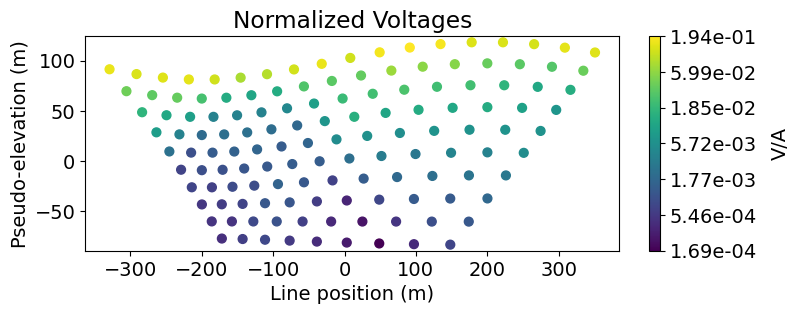

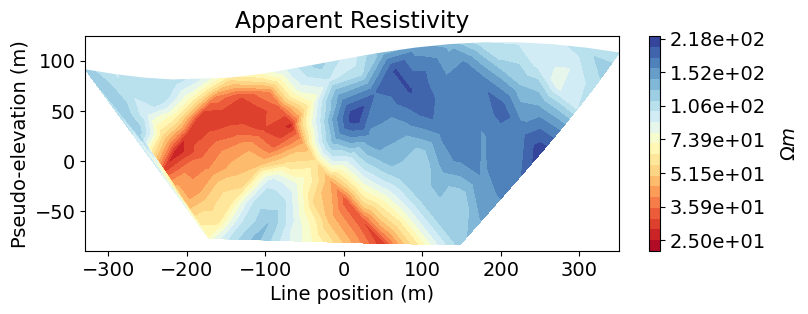

In [17]:
# Plot voltages pseudo-section
fig = plt.figure(figsize=(8, 2.75))
ax1 = fig.add_axes([0.1, 0.15, 0.75, 0.78])
plot_pseudosection(
    voltage_data,
    plot_type="scatter",
    ax=ax1,
    scale="log",
    cbar_label="V/A",
    scatter_opts={"cmap": mpl.cm.viridis},
)
ax1.set_title("Normalized Voltages")
plt.show()

# Get apparent conductivities from volts and survey geometry
apparent_resistivities = apparent_resistivity_from_voltage(
    voltage_data.survey, voltage_data.dobs
)

# Plot apparent resistivity pseudo-section
fig = plt.figure(figsize=(8, 2.75))
ax1 = fig.add_axes([0.1, 0.15, 0.75, 0.78])
plot_pseudosection(
    voltage_data.survey,
    apparent_resistivities,
    plot_type="contourf",
    ax=ax1,
    scale="log",
    cbar_label=r"$\Omega m$",
    mask_topography=True,
    contourf_opts={"levels": 20, "cmap": mpl.cm.RdYlBu},
)
ax1.set_title("Apparent Resistivity")
plt.show()

## Assign Uncertainties

Inversion with SimPEG requires that we define the uncertainties on our data; that is, an estimate of the standard deviation of the noise on our data assuming it is uncorrelated Gaussian with zero mean. An online resource explaining uncertainties and their role in the inversion can be found [here](https://giftoolscookbook.readthedocs.io/en/latest/content/fundamentals/Uncertainties.html).

**For normalized voltage data,** we generally apply a percent uncertainty and a very small floor uncertainty to all data. Differences in electrode spacing and subsurface conductivity result in measured voltages that span many orders of magnitude. A percent uncertainty ensures all data are fit equally. Depending on the quality of the data, we may choose a percent uncertainty between 2% - 10%. The floor uncertainty ensures stability when there are zero-crossings or erroneously small voltages. Here, we apply uncertainties of 1e-7 V/A + 5 %.

In [ ]:
# Apply uncertainties to normalized voltage data 

## Design a (Tree) Mesh

The same rules for defining appropriate meshes for forward simulation of DC resistivity apply to inversion. Please visit the [2.5D Forward Simulation](fwd_dcr_2d.ipynb) tutorial to see the best practices for mesh design.

**Tutorial mesh:** Here, a minimum cell width of 4 m (or 1/10 the minimum electrode spacing) is used within our survey region. The largest electrode spacing was 400 m, so a the padding was extended at least 1200 m from the survey region. Using the [refine_surface](xref:discretize#discretize.TreeMesh.refine_surface) method, we refine the tree mesh where there is significant topography. And using the [refine_points](xref:discretize#discretize.TreeMesh.refine_points) methods, we refine based on electrodes locations. Visit the [tree mesh](xref:discretize#discretize.TreeMesh) API to see additional refinement methods.

In [19]:
dh = 4  # base cell width
dom_width_x = 3200.0  # domain width x
dom_width_z = 2400.0  # domain width z
nbcx = 2 ** int(np.round(np.log(dom_width_x / dh) / np.log(2.0)))  # num. base cells x
nbcz = 2 ** int(np.round(np.log(dom_width_z / dh) / np.log(2.0)))  # num. base cells z

# Define the base mesh with top at z = 0 m
hx = [(dh, nbcx)]
hz = [(dh, nbcz)]
mesh = TreeMesh([hx, hz], x0="CN", diagonal_balance=True)

# Shift top to maximum topography
mesh.origin = mesh.origin + np.r_[0.0, topo_2d[:, -1].max()]

# Mesh refinement based on topography
mesh.refine_surface(
    topo_2d,
    padding_cells_by_level=[0, 0, 4, 4],
    finalize=False,
)

# Extract unique electrode locations.
unique_locations = voltage_data.survey.unique_electrode_locations

# Mesh refinement near electrodes.
mesh.refine_points(
    unique_locations, padding_cells_by_level=[8, 12, 6, 6], finalize=False
)

mesh.finalize()

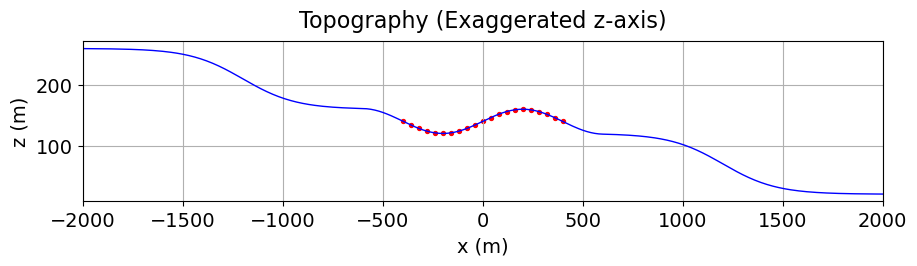

In [20]:
# Plot 2D topography
fig = plt.figure(figsize=(10, 2))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(topo_2d[:, 0], topo_2d[:, -1], color="b", linewidth=1)
ax.scatter(unique_locations[:, 0], unique_locations[:, 1], 8, "r")
ax.set_xlim([topo_2d[:, 0].min(), topo_2d[:, 0].max()])
ax.set_xlabel("x (m)", labelpad=5)
ax.set_ylabel("z (m)", labelpad=5)
ax.grid(True)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=10)
plt.show(fig)

## Plot results in terms of conductivity

In [ ]:
# Recreate the true model
true_background_conductivity = 1e-2
true_conductor_conductivity = 1e-1
true_resistor_conductivity = 1e-3

true_conductivity_model = true_background_conductivity * np.ones(n_active)

ind_conductor = model_builder.get_indices_sphere(
    np.r_[-120.0, 40.0], 60.0, mesh.cell_centers[active_cells, :]
)
true_conductivity_model[ind_conductor] = true_conductor_conductivity

ind_resistor = model_builder.get_indices_sphere(
    np.r_[120.0, 72.0], 60.0, mesh.cell_centers[active_cells, :]
)
true_conductivity_model[ind_resistor] = true_resistor_conductivity

In [ ]:
# Convert recovered log-resistivities to conductivities
recovered_conductivity_irls = 1 / np.exp(recovered_log_resistivity_model)

In [ ]:
# Convert to subsurface conductivity values
plotting_model = [
    true_conductivity_model,
    recovered_conductivity_L2,
    recovered_conductivity_irls,
]

fig = plt.figure(figsize=(9, 13))
ax1 = 3 * [None]
ax2 = 3 * [None]
title_str = [
    "True Conductivity Model",
    "Recovered Model (L2)",
    "Recovered Model (IRLS)",
]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.14, 0.75 - 0.3 * ii, 0.68, 0.22])
    mesh.plot_image(
        plotting_map * plotting_model[ii],
        ax=ax1[ii],
        grid=False,
        pcolor_opts={"norm": norm, "cmap": mpl.cm.RdYlBu_r},
    )
    ax1[ii].set_xlim(-500, 500)
    ax1[ii].set_ylim(-300, 200)
    ax1[ii].set_title(title_str[ii])
    ax1[ii].set_xlabel("x (m)")
    ax1[ii].set_ylabel("z (m)")

    ax2[ii] = fig.add_axes([0.84, 0.75 - 0.3 * ii, 0.03, 0.22])
    cbar = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r
    )
    cbar.set_label(r"$\sigma$ (S/m)", rotation=270, labelpad=15, size=12)

plt.show()